# **Day 70: Self-Supervised and Contrastive Learning**
*Module 11 - Advanced Deep Learning*

Satellites collect **petabytes** of imagery every year, but only a tiny fraction is labelled. **Self-supervised learning (SSL)** learns useful representations from unlabelled data by solving a **pretext task** whose labels come from the data itself. A small labelled set is then enough for the downstream task. SSL is how modern Earth-observation foundation models (SSL4EO, SatMAE, Prithvi, Clay) are built.

> Self-supervised learning creates its own training signal from unlabelled data. Contrastive methods learn that two altered views of the same image should look alike, and views of different images should not.
>
> *Example:* Two crops of the same village patch, one darker and one rotated, should get similar embeddings, without anyone labelling "village".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, copy, time
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
torch.manual_seed(70); rng = np.random.default_rng(70)

VEG = [0.04, 0.07, 0.05, 0.30]      # forest, cropland and grassland share ONE mean spectrum: only spatial texture separates them
SPECTRA = {"water": [0.06, 0.05, 0.03, 0.02], "forest": VEG, "cropland": VEG, "grassland": VEG,
           "urban": [0.12, 0.12, 0.13, 0.20], "bare_soil": [0.13, 0.15, 0.18, 0.24]}
CLASSES = list(SPECTRA)

def _norm(t): return (t - t.mean()) / (t.std() + 1e-9)

def make_patch(cls, r, size=32):
    s = np.array(SPECTRA[cls]) * r.uniform(0.75, 1.25) * r.uniform(0.9, 1.1, 4)          # brightness + per-band variation
    yy, xx = np.mgrid[0:size, 0:size]
    if cls == "water": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 6))
    elif cls == "forest": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 0.8))      # fine, rough canopy
    elif cls == "cropland":
        a, per = r.uniform(0, np.pi), r.uniform(5, 10); tex = _norm(np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per))   # field stripes
    elif cls == "grassland": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 3))       # smooth patches
    elif cls == "urban":
        b = r.integers(4, 8); tex = _norm((((xx // b) % 2) ^ ((yy // b) % 2)).astype(float))    # block grid
    else: tex = _norm(gaussian_filter(r.normal(size=(size, size)), 4))
    return (s[:, None, None] * (1 + r.uniform(0.15, 0.3) * tex[None]) + r.normal(0, 0.012, (4, size, size))).astype(np.float32)
def make_ds(n, seed):
    r = np.random.default_rng(seed); X = np.stack([make_patch(c, r) for c in SPECTRA for _ in range(n)]); return X, np.repeat(np.arange(6), n)

X_unl, _ = make_ds(400, 1)                      # 2400 UNLABELLED patches (labels discarded)
X_lab, y_lab = make_ds(10, 2)                   # only 10 labelled patches per class
X_te, y_te = make_ds(150, 3)
mu, sd = X_unl.mean((0, 2, 3), keepdims=True), X_unl.std((0, 2, 3), keepdims=True)
nrm = lambda a: torch.tensor((a - mu) / sd)
print(f"unlabelled {len(X_unl)} | labelled {len(X_lab)} | test {len(X_te)}")

unlabelled 2400 | labelled 60 | test 900


## **1. Pretext Tasks**

| Pretext task | Labels come from | Learns |
|---|---|---|
| Rotation prediction (Gidaris et al., 2018) | which of 4 rotations was applied | orientation-sensitive structure |
| Inpainting / **masked autoencoding** | hidden pixels/patches | context, texture, spectra |
| **Contrastive instance discrimination** | "two augmentations of the same image are a positive pair" | invariances chosen by the augmentations |
| Temporal / geographic positives (RS) | same location at different dates; nearby locations | seasonal invariance, spatial semantics |

## **2. Contrastive Learning: SimCLR From Scratch**
1. Take a batch of N images; create **two random augmentations** of each -> 2N views.
2. Encode with a CNN $f$, then a small MLP **projection head** $g$: $\mathbf z = g(f(\mathbf x))$, L2-normalised.
3. **NT-Xent / InfoNCE loss**: each view must identify its partner among the other 2N-1 views:
$$\ell_{i,j} = -\log\frac{\exp(\text{sim}(\mathbf z_i,\mathbf z_j)/\tau)}{\sum_{k\neq i}\exp(\text{sim}(\mathbf z_i,\mathbf z_k)/\tau)}$$
4. After training, discard $g$ and use $f$'s features.

The augmentations define what the representation ignores: flips/rotations (orientation), brightness/band jitter (illumination), crops (position), noise.

SimCLR pretraining: 273s | loss 3.98 -> 2.56  (chance level ln(255) = 5.54)


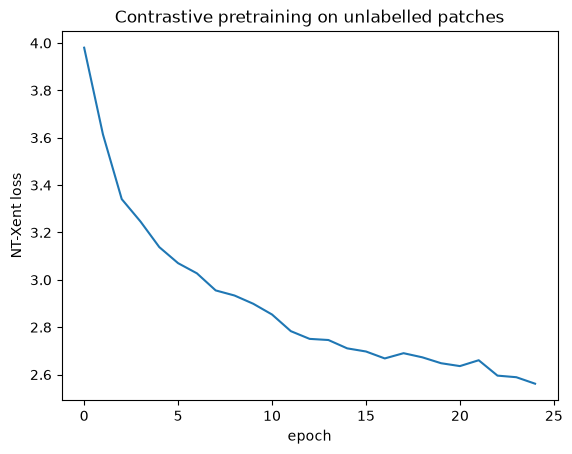

In [2]:
def augment(x):                                             # x: (B, C, H, W) normalised tensor
    B = x.shape[0]
    k = np.random.randint(4); x = torch.rot90(x, k, (2, 3))
    if np.random.rand() < 0.5: x = torch.flip(x, (3,))
    scale = torch.empty(B, 1, 1, 1).uniform_(0.7, 1.3); shift = torch.empty(B, x.shape[1], 1, 1).uniform_(-0.3, 0.3)
    x = x * scale + shift                                   # illumination + per-band offset (in normalised units)
    crop = np.random.randint(20, 33); i, j = np.random.randint(0, 33 - crop, 2)
    x = F.interpolate(x[:, :, i:i + crop, j:j + crop], size=32, mode="bilinear", align_corners=False)   # random resized crop
    return x + 0.1 * torch.randn_like(x)

class Encoder(nn.Module):
    def __init__(self, d=128):
        super().__init__(); blk = lambda ci, co: nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.net = nn.Sequential(blk(4, 32), blk(32, 64), blk(64, d), nn.AdaptiveAvgPool2d(1), nn.Flatten())
    def forward(self, x): return self.net(x)

def nt_xent(z1, z2, tau=0.2):
    z = F.normalize(torch.cat([z1, z2]), dim=1); N = len(z1)
    sim = z @ z.T / tau; sim.fill_diagonal_(float("-inf"))                     # a view is never its own negative
    targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)])          # the partner of view i is i+N (and vice versa)
    return F.cross_entropy(sim, targets)

encoder = Encoder(); proj = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 64))
opt = torch.optim.AdamW(list(encoder.parameters()) + list(proj.parameters()), 1e-3, weight_decay=1e-4)
dl = DataLoader(TensorDataset(nrm(X_unl)), batch_size=128, shuffle=True, drop_last=True)
t0 = time.perf_counter(); hist = []
for epoch in range(25):
    encoder.train(); tot = 0
    for (xb,) in dl:
        loss = nt_xent(proj(encoder(augment(xb))), proj(encoder(augment(xb))))
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
    hist.append(tot / len(dl))
print(f"SimCLR pretraining: {time.perf_counter() - t0:.0f}s | loss {hist[0]:.2f} -> {hist[-1]:.2f}  (chance level ln(255) = {np.log(255):.2f})")
plt.plot(hist); plt.xlabel("epoch"); plt.ylabel("NT-Xent loss"); plt.title("Contrastive pretraining on unlabelled patches"); plt.show()

## **3. Evaluating the Representation With Few Labels**
**Linear probe**: freeze the encoder, extract features, train a logistic regression on the 60 labelled patches. Compare against: a randomly initialised encoder, a CNN trained end-to-end on the 60 labels, and hand-crafted band statistics.

In [3]:
def features(enc, X):
    enc.eval()
    with torch.no_grad(): return enc(nrm(X)).numpy()

def probe(enc):
    lr = LogisticRegression(max_iter=5000, C=1.0).fit(features(enc, X_lab), y_lab)
    knn = KNeighborsClassifier(5).fit(features(enc, X_lab), y_lab)
    return lr.score(features(enc, X_te), y_te), knn.score(features(enc, X_te), y_te)

torch.manual_seed(0); random_enc = Encoder()
sup = Encoder(); head = nn.Linear(128, 6); o = torch.optim.AdamW(list(sup.parameters()) + list(head.parameters()), 1e-3)
for ep in range(60):
    sup.train(); xb = augment(nrm(X_lab)); loss = F.cross_entropy(head(sup(xb)), torch.tensor(y_lab)); o.zero_grad(); loss.backward(); o.step()
sup.eval()
with torch.no_grad(): sup_acc = (head(sup(nrm(X_te))).argmax(1).numpy() == y_te).mean()
stats_feat = lambda X: np.c_[X.mean((2, 3)), X.std((2, 3))]
rows = {"random encoder + linear probe": probe(random_enc)[0], "SimCLR encoder + linear probe": probe(encoder)[0], "SimCLR encoder + 5-NN": probe(encoder)[1],
        "supervised CNN on 60 labels (with augmentation)": sup_acc,
        "logistic regression on band mean/std": LogisticRegression(max_iter=5000).fit(stats_feat(X_lab), y_lab).score(stats_feat(X_te), y_te)}
pd.Series(rows, name="test accuracy (10 labels per class)").round(3)

random encoder + linear probe                      0.747
SimCLR encoder + linear probe                      0.946
SimCLR encoder + 5-NN                              0.859
supervised CNN on 60 labels (with augmentation)    0.892
logistic regression on band mean/std               0.482
Name: test accuracy (10 labels per class), dtype: float64

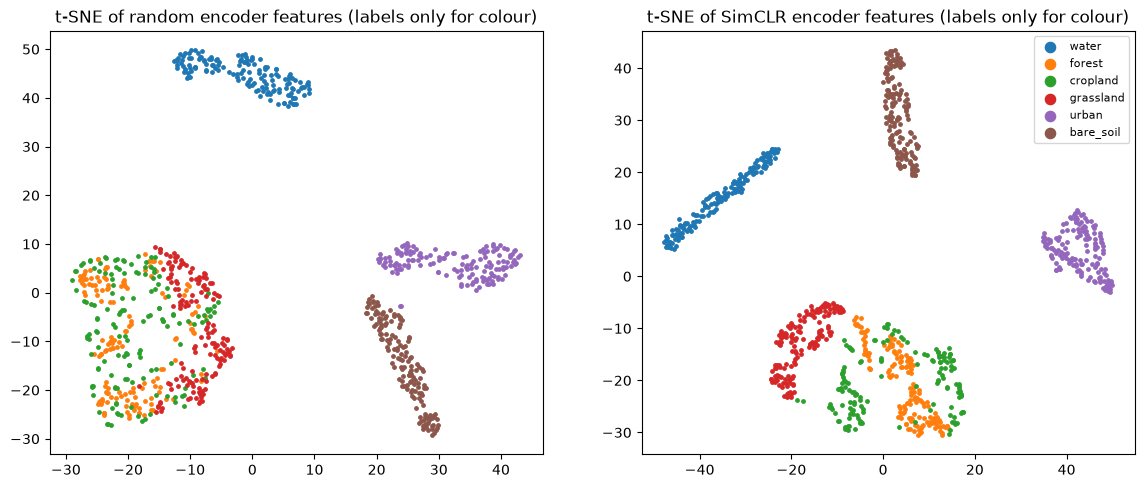

In [4]:
from sklearn.manifold import TSNE
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (name, enc) in zip(axes, [("random encoder", random_enc), ("SimCLR encoder", encoder)]):
    emb = TSNE(2, random_state=0).fit_transform(features(enc, X_te))
    for k, c in enumerate(SPECTRA): ax.scatter(*emb[y_te == k].T, s=6, label=c)
    ax.set_title(f"t-SNE of {name} features (labels only for colour)")
axes[1].legend(markerscale=3, fontsize=8); plt.show()

## **4. Masked Autoencoders (MAE)**
He et al. (2022): hide a large fraction (e.g. 75%) of image patches and train the model to **reconstruct** them. To fill in a hidden field patch, the model must understand textures and spectra from context. Below is a compact convolutional version: mask random 8x8 blocks, reconstruct the full patch, compute the loss only on masked pixels.

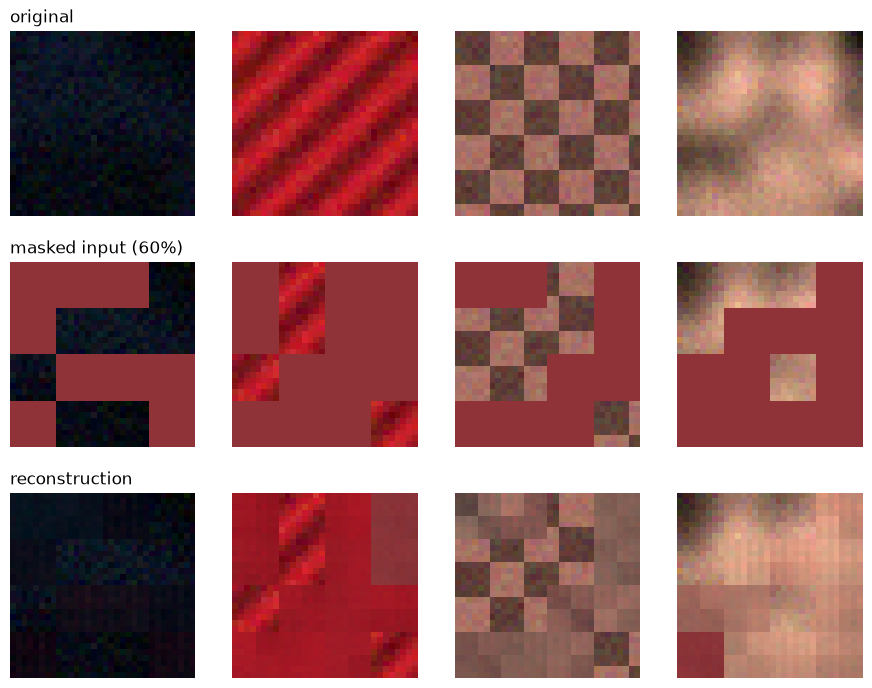

MAE encoder + linear probe accuracy: 0.863


In [5]:
class MaskedAE(nn.Module):
    def __init__(self):
        super().__init__(); self.enc = Encoder().net[:3]                         # conv blocks without global pooling
        self.dec = nn.Sequential(nn.ConvTranspose2d(128, 64, 2, 2), nn.ReLU(), nn.ConvTranspose2d(64, 32, 2, 2), nn.ReLU(), nn.ConvTranspose2d(32, 4, 2, 2))
    def forward(self, x): return self.dec(self.enc(x))
def block_mask(B, ratio=0.6, grid=4, size=32):
    m = (torch.rand(B, 1, grid, grid) < ratio).float(); return F.interpolate(m, size=size, mode="nearest")   # 1 = hidden
mae = MaskedAE(); o = torch.optim.AdamW(mae.parameters(), 1e-3)
for epoch in range(15):
    for (xb,) in dl:
        m = block_mask(len(xb)); rec = mae(xb * (1 - m)); loss = (((rec - xb) ** 2) * m).sum() / (m.sum() * 4)
        o.zero_grad(); loss.backward(); o.step()
mae.eval(); xs = nrm(X_te[[0, 300, 600, 750]]); m = block_mask(4)
with torch.no_grad(): rec = mae(xs * (1 - m))
show = lambda t: np.clip((t.numpy() * sd[0] + mu[0])[[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)
fig, axes = plt.subplots(3, 4, figsize=(11, 8.5))
for j in range(4):
    axes[0, j].imshow(show(xs[j])); axes[1, j].imshow(show(xs[j] * (1 - m[j]))); axes[2, j].imshow(show(rec[j] * m[j] + xs[j] * (1 - m[j])))
for ax in axes.ravel(): ax.axis("off")
for i, t in enumerate(["original", "masked input (60%)", "reconstruction"]): axes[i, 0].set_title(t, loc="left")
plt.show()
mae_enc = nn.Sequential(mae.enc, nn.AdaptiveAvgPool2d(1), nn.Flatten())
print("MAE encoder + linear probe accuracy:", round(LogisticRegression(max_iter=5000).fit(features(mae_enc, X_lab), y_lab).score(features(mae_enc, X_te), y_te), 3))

# **Part 2: Going Deeper**

### Representation collapse
If the loss only asked "make the two views similar", the trivial solution is to map **every** image to the same vector. Methods avoid **collapse** differently:
- **Negatives** (SimCLR, MoCo): push other images away (needs large batches or a memory queue).
- **Asymmetry + stop-gradient** (BYOL, SimSiam): a predictor on one branch and no gradient through the other.
- **Variance/covariance regularisation** (VICReg, Barlow Twins): keep embedding dimensions informative and decorrelated.
- **Reconstruction** (MAE): cannot collapse because it must reproduce the input.

In [6]:
def similarity_only_loss(z1, z2): return -F.cosine_similarity(z1, z2).mean()
enc_c = Encoder(); proj_c = nn.Sequential(nn.Linear(128, 64)); o = torch.optim.AdamW(list(enc_c.parameters()) + list(proj_c.parameters()), 1e-3)
for epoch in range(5):
    for (xb,) in dl:
        loss = similarity_only_loss(proj_c(enc_c(augment(xb))), proj_c(enc_c(augment(xb)))); o.zero_grad(); loss.backward(); o.step()
z_c = proj_c(enc_c(nrm(X_te[:300]))).detach(); z_s = proj(encoder(nrm(X_te[:300]))).detach()
print(f"mean per-dimension std of normalised embeddings: similarity-only {F.normalize(z_c, dim=1).std(0).mean():.4f} (collapsed) | SimCLR {F.normalize(z_s, dim=1).std(0).mean():.4f}")

mean per-dimension std of normalised embeddings: similarity-only 0.0244 (collapsed) | SimCLR 0.0986


### Self-supervision designed for remote sensing
- **Seasonal contrast** (SeCo, Manas et al., 2021): positives = same place at different dates -> invariance to season.
- **Geography-aware SSL** (Ayush et al., 2021): spatially nearby images as positives + predicting location.
- **Multi-modal** positives: Sentinel-1 SAR and Sentinel-2 optical of the same place (SSL4EO-S12).
- **Masked autoencoders on multispectral, multitemporal data** (SatMAE, Prithvi), with spectral-group and temporal encodings.

## **Practice Problems**
1. Remove the random crop from `augment` and retrain SimCLR (10 epochs). How does the linear-probe accuracy change? Which augmentations matter most?
2. Vary the temperature tau (0.05, 0.2, 1.0). What happens?
3. Fine-tune the SimCLR encoder end-to-end on the 60 labels (small learning rate) and compare with the linear probe.
4. *(Advanced)* Implement a **rotation-prediction** pretext task (4-way classification of the applied rotation) and compare its linear probe with SimCLR. (Hint: for nadir images rotation is ambiguous, so expect weaker features.)

In [7]:
def simclr(aug_fn, epochs=10, tau=0.2, seed=0):
    torch.manual_seed(seed); enc = Encoder(); pj = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 64))
    o_ = torch.optim.AdamW(list(enc.parameters()) + list(pj.parameters()), 1e-3)
    for _ in range(epochs):
        for (xb,) in dl:
            l_ = nt_xent(pj(enc(aug_fn(xb))), pj(enc(aug_fn(xb))), tau); o_.zero_grad(); l_.backward(); o_.step()
    return enc
# Solution 1
def augment_no_crop(x):
    k = np.random.randint(4); x = torch.rot90(x, k, (2, 3)); x = x * torch.empty(len(x), 1, 1, 1).uniform_(0.7, 1.3) + torch.empty(len(x), 4, 1, 1).uniform_(-0.3, 0.3)
    return x + 0.1 * torch.randn_like(x)
print("no random crop: linear probe", round(probe(simclr(augment_no_crop))[0], 3), "| full augmentations (10 epochs):", round(probe(simclr(augment))[0], 3))
# Solution 2
for tau in [0.05, 1.0]: print(f"tau {tau}: linear probe {probe(simclr(augment, tau=tau))[0]:.3f}")
# Solution 3
ft = copy.deepcopy(encoder); hd = nn.Linear(128, 6); o = torch.optim.AdamW([{"params": ft.parameters(), "lr": 1e-4}, {"params": hd.parameters(), "lr": 1e-3}])
for ep in range(60):
    ft.train(); l_ = F.cross_entropy(hd(ft(augment(nrm(X_lab)))), torch.tensor(y_lab)); o.zero_grad(); l_.backward(); o.step()
ft.eval()
with torch.no_grad(): print("SimCLR + fine-tuning:", round((hd(ft(nrm(X_te))).argmax(1).numpy() == y_te).mean(), 3))
# Solution 4
torch.manual_seed(0); rot_enc = Encoder(); rot_head = nn.Linear(128, 4); o = torch.optim.AdamW(list(rot_enc.parameters()) + list(rot_head.parameters()), 1e-3)
for _ in range(10):
    for (xb,) in dl:
        k = torch.randint(0, 4, (len(xb),)); xr = torch.stack([torch.rot90(x, int(kk), (1, 2)) for x, kk in zip(xb, k)])
        l_ = F.cross_entropy(rot_head(rot_enc(xr)), k); o.zero_grad(); l_.backward(); o.step()
print("rotation-prediction encoder + linear probe:", round(probe(rot_enc)[0], 3))

no random crop: linear probe 0.947 | full augmentations (10 epochs): 0.941


tau 0.05: linear probe 0.944


tau 1.0: linear probe 0.884


SimCLR + fine-tuning: 0.861


rotation-prediction encoder + linear probe: 0.88


## **Key References**
- Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020). A simple framework for contrastive learning of visual representations. *ICML 2020* (SimCLR).
- He, K., Fan, H., Wu, Y., Xie, S., & Girshick, R. (2020). Momentum contrast for unsupervised visual representation learning. *CVPR 2020* (MoCo).
- Grill, J.-B. et al. (2020). Bootstrap your own latent: A new approach to self-supervised learning. *NeurIPS 33* (BYOL).
- He, K. et al. (2022). Masked autoencoders are scalable vision learners. *CVPR 2022*.
- Manas, O., Lacoste, A., Giro-i-Nieto, X., Vazquez, D., & Rodriguez, P. (2021). Seasonal contrast: Unsupervised pre-training from uncurated remote sensing data. *ICCV 2021*.
- Wang, Y., Albrecht, C. M., Ait Ali Braham, N., Mou, L., & Zhu, X. X. (2022). Self-supervised learning in remote sensing: A review. *IEEE Geoscience and Remote Sensing Magazine*, 10(4), 213-247.